# Checking the performance of `pympc` positions vs SkyBot

Here we use a large search cone to find accurate positions of minor bodies from [SkyBoT](https://ssp.imcce.fr/webservices/skybot/) cone searches and compare them to `pympc` positions. We will compare the difference in positions as a function of temporal distance from the osculation epoch of the `pympc` base catalogue.

**Summary of Results**
> Vast majority of `pympc` matches remain within a few arcseconds of online `SkyBoT` positions for up to 8 weeks difference between querying epoch and osculation epoch of the catalogue. This should be a worst case scenario, if performing real-time checking and regular catalogue fetching, given the update frequency of ASTORB catalogue epochs. Most (83%) remain with a few arcsconds even at 16 weeks, but this is likely to degrade steeply with longer epoch separations. Regularly updating the local catalogue will help to mitigate this issue.



### Query epoch vs. Base catalogue osculation epoch

We will test scenarios involving increasing separation of the epochs between when we are requesting `pympc` position of objects (*query epoch*) and when the orbital elements are computed for in the local ephemeris catalogue (*osculation epoch*). One scenario is an idealised case where the epochs are the same, and we check separations of 1,2,4,8,16 weeks. The check is done against ASTORB catalogue, which aims to provide updates within +/-50 days (~8 weeks) of the current epoch. So if regularly updating the catalogue, and only search in real-time, this should be a worse-case scenario for matching accuracy. The Minor Planet Center update MPCORB catalogue osculation epoch is updated roughly every 6 months, so the performance can degrade further in worst-case scenarios. We check `pympc` against ASTORB for now.

## Setup

In [12]:
from pathlib import Path
from datetime import timedelta

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import requests

from astropy.io import ascii
from astropy.coordinates import SkyCoord
from astropy.table import Table, join
from astropy.time import Time

import pympc

The worker function to query SkyBoT:

In [14]:
def query_skybot(ra, dec, rad, epoch, maglim=30, loc=500):
    """
    Query skybot, using text-parser instead of XML parser to avoid bugs.
    NB: be kind using this, as continuous querying with high thread counts will lead to **severe** throttling
    :param ra: RA in decimal degrees
    :param dec: DEC in decimal degrees
    :param rad: Search radius in decimal degrees
    :param epoch: Date of observation in JD
    :param maglim: Faintest objects we want to consider
    :param loc: MPC code for observatory
    :return: Table of detections, or None
    """
    querystring = "-ep={}&-ra={}&-dec={}&-loc={}&-rd={}&-output=object&-mime=text".format(epoch, ra, dec, loc, rad)
    queryurl = "https://ssp.imcce.fr/webservices/skybot/api/conesearch.php?" + querystring
    print(f"(querying {queryurl})")
    httpreq = requests.get(queryurl)
    response = httpreq.text.split("\n")
    # Catch empty requests
    if len(response) <= 4:
        return None
    # Extract header and message content
    response_header = response[2].strip('#').split(' | ')
    response_table = response[3:]
    results_table = ascii.read(response_table, delimiter='|', names=response_header)
    results_table = Table(results_table)

    results_table = results_table[results_table["Mv"] < maglim]
    # Catch case if we have zero detections above mlim
    if len(results_table) == 0:
        return None
    return results_table

### Update catalogue

Here we update once the `pympc` local catalogue, which fixes our reference epoch

In [3]:
cat_dir="/tmp/pympc_asteroids_position_check"
# xephem_filepath = pympc.update_catalogue(cat_dir=cat_dir, include_comets=False, include_nea=False, show_progress=False, source="astorb")

In [9]:
xephem_filepath = str(Path(cat_dir) / "xephem" / "xephem_astorb.csv")

In [10]:
# Get the reference epoch of the downloaded data
with open(xephem_filepath) as f:
    line = f.readline()
epoch_decimalyear = line.split(",")[9]
print(f"Reference epoch is {Time(epoch_decimalyear, format='decimalyear').iso}")

Reference epoch is 2026-06-08 23:58:50.673


#### Search and store SkyBoT results for increasing epoch separations

A 5-degree cone centred on ra=dec=0 was searched via the [SkyBoT cone search](https://ssp.imcce.fr/webservices/skybot/api/conesearch/) service using the reference epoch date and plus 1,2,4,8,16 weeks from that date, with geocentric positions (observatory code 500).


In [35]:
epochs = [
    Time(epoch_decimalyear, format='decimalyear') + timedelta(weeks=delta_week)
    for delta_week in [0, 1, 2, 4, 8, 16]
]
skybot_results = []

for epoch in epochs:
    print(f"Querying SkyBoT for epoch {epoch.iso}")
    skybot_result = query_skybot(ra=0, dec=10, rad=3, epoch=epoch.jd, maglim=30, loc=500)
    if skybot_result is not None:
        skybot_result["skybot_coords"] = SkyCoord(ra=skybot_result["RA(h)"], dec=skybot_result["DE(deg)"], unit=(u.hourangle, u.deg))
    print(f"Got {len(skybot_result) if skybot_result is not None else 0} results")
    skybot_results.append(skybot_result)

Querying SkyBoT for epoch 2026-06-08 23:58:50.673
https://ssp.imcce.fr/webservices/skybot/api/conesearch.php?-ep=2461200.4991976&-ra=0&-dec=10&-loc=500&-rd=3&-output=object&-mime=text
Got 1870 results
Querying SkyBoT for epoch 2026-06-15 23:58:50.673
https://ssp.imcce.fr/webservices/skybot/api/conesearch.php?-ep=2461207.4991976&-ra=0&-dec=10&-loc=500&-rd=3&-output=object&-mime=text
Got 1716 results
Querying SkyBoT for epoch 2026-06-22 23:58:50.673
https://ssp.imcce.fr/webservices/skybot/api/conesearch.php?-ep=2461214.4991976&-ra=0&-dec=10&-loc=500&-rd=3&-output=object&-mime=text
Got 1627 results
Querying SkyBoT for epoch 2026-07-06 23:58:50.673
https://ssp.imcce.fr/webservices/skybot/api/conesearch.php?-ep=2461228.4991976&-ra=0&-dec=10&-loc=500&-rd=3&-output=object&-mime=text
Got 1557 results
Querying SkyBoT for epoch 2026-08-03 23:58:50.673
https://ssp.imcce.fr/webservices/skybot/api/conesearch.php?-ep=2461256.4991976&-ra=0&-dec=10&-loc=500&-rd=3&-output=object&-mime=text
Got 1319 res

#### Perform the same searches with `pympc` offline

We add a generous buffer to the radius used for `pympc` vs that for SkyBoT in order to capture all matches, even those at the edge of the original search cone.

A function to call `pympc` at a given epoch

In [36]:
def get_pympc_results(xephem, ra, dec, search_radius, epoch, max_mag=30, obs_code=500):
    pympc_tbl_ = pympc.minor_planet_check(ra, dec, epoch, search_radius, xephem_filepath=xephem, max_mag=max_mag, observatory=obs_code)
    pympc_tbl_["pympc_coords"] = SkyCoord(ra=pympc_tbl_["ra"], dec=pympc_tbl_["dec"], unit=(u.deg, u.deg))
    del pympc_tbl_["xephem_str"]
    return pympc_tbl_

In [37]:
pympc_results = []
for epoch in epochs:
    pympc_tbl = get_pympc_results(xephem_filepath, ra=0, dec=10, search_radius=5 * u.deg, epoch=epoch, max_mag=30, obs_code=500)
    print(f"Got {len(pympc_tbl)} results for epoch {epoch.iso}")
    pympc_results.append(pympc_tbl)

Got 6167 results for epoch 2026-06-08 23:58:50.673
Got 5924 results for epoch 2026-06-15 23:58:50.673
Got 5688 results for epoch 2026-06-22 23:58:50.673
Got 5286 results for epoch 2026-07-06 23:58:50.673
Got 4375 results for epoch 2026-08-03 23:58:50.673
Got 3501 results for epoch 2026-09-28 23:58:50.673


#### Compare the results

In [38]:
seps = []
numbermatcheds = []
numberskybots = []
for skybot_result, pympc_tbl in zip(skybot_results, pympc_results):
    # Join the tables so that we can easily access the coordinates from each
    joined_tbl = join(pympc_tbl, skybot_result, keys_left="name", keys_right="Name")
    numbermatched = len(joined_tbl)
    numberskybot = len(skybot_result) if skybot_result is not None else 0
    sep = joined_tbl[f"skybot_coords"].separation(joined_tbl[f"pympc_coords"]).to(u.arcsec)
    seps.append(sep)
    numbermatcheds.append(numbermatched)
    numberskybots.append(numberskybot)

Epoch: 0 weeks
	1867/1870 SkyBoT sources also found by pympc
	98.23% of the SkyBot results are within 1 arcsec of pympc positions
	99.73% of the SkyBot results are within 4 arcsec of pympc positions
	0.392 arcsec is the median separation
-------------------------------------------------------------------------------
Epoch: +1 weeks
	1713/1716 SkyBoT sources also found by pympc
	94.98% of the SkyBot results are within 1 arcsec of pympc positions
	99.30% of the SkyBot results are within 4 arcsec of pympc positions
	0.421 arcsec is the median separation
-------------------------------------------------------------------------------
Epoch: +2 weeks
	1622/1627 SkyBoT sources also found by pympc
	95.44% of the SkyBot results are within 1 arcsec of pympc positions
	99.57% of the SkyBot results are within 4 arcsec of pympc positions
	0.425 arcsec is the median separation
-------------------------------------------------------------------------------
Epoch: +4 weeks
	1554/1557 SkyBoT sources al

Text(0.5, 1.0, 'Separation of pympc and SkyBoT positions vs weeks from osclusion epoch')

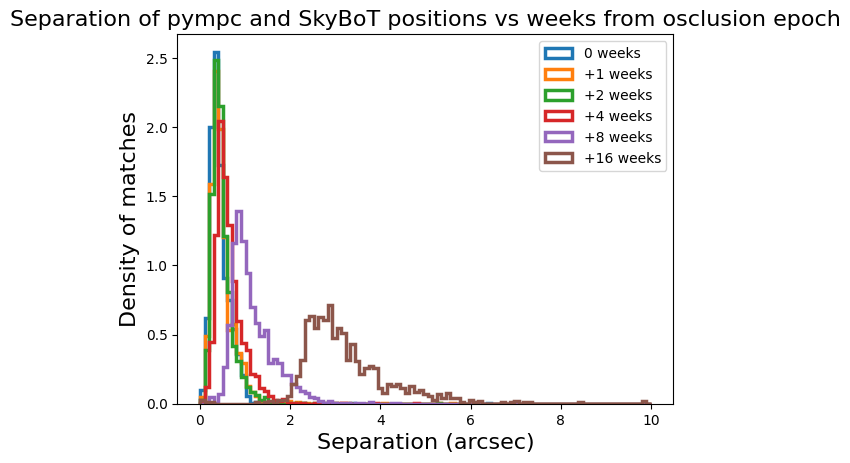

In [40]:
epoch_names = [f"+{delta_week} weeks" if delta_week > 0 else "0 weeks" for delta_week in [0, 1, 2, 4, 8, 16]]

for epoch_name, sep, n_matched, n_skybot in zip (epoch_names, seps, numbermatcheds, numberskybots):
    _ = plt.hist(sep.value, bins=np.linspace(0, 10, 100), density=True, histtype="step", lw=2.5, label=f"{epoch_name}")
    print(f"Epoch: {epoch_name}")
    print(f"\t{n_matched}/{n_skybot} SkyBoT sources also found by pympc")
    print(f"\t{100*np.sum(sep < 1 * u.arcsec)/len(sep):.2f}% of the SkyBot results are within 1 arcsec of pympc positions")
    print(f"\t{100*np.sum(sep < 4 * u.arcsec)/len(sep):.2f}% of the SkyBot results are within 4 arcsec of pympc positions")
    print(f"\t{np.median(sep):.3f} is the median separation")
    print("-"*79)

plt.legend(frameon=True)
plt.xlabel("Separation (arcsec)", size=16)
plt.ylabel("Density of matches", size=16)
plt.title("Separation of pympc and SkyBoT positions vs weeks from osculation epoch", size=16)
# plt.savefig("position_accuracy.png")